In [27]:
# Dataframe manipulation
import pandas as pd
import datetime as dt

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [28]:
def plot_style(ax):
    sns.despine(top=True, right=True, left=False, bottom=False)
    ax.spines['bottom'].set_color('gray')
    ax.spines['left'].set_color('gray')
    ax.tick_params(colors='gray')
    ax.xaxis.label.set_color('gray')
    ax.yaxis.label.set_color('gray')

In [29]:
# Locally method
df = pd.read_csv('../dataset/raw/TRIAGE_2024.csv')

In [31]:
df.head()

,3+-99999|a,[ñ_MJ,NOMBRE Y APELLIDO,MOTIVO DE CONSULTA,BOX,TRIAGE,ENFERMERO,MEDICO,DESTINO,A,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,FECHA: 01/01/2024 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,01-01,LUSI,FIEBRE Y TOS,18,IV,ERIKA,RODRIGO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,01-01,LO PINTO CARLOS,FIEBRE Y TOS,17,IV,SOLEDAD G,SOLEDAD,alta,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,01-01,BANDERA,TOS,12,IV,ERIKA,RODRIGO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,01-01,TOMINO EDUARDO,HTA,12,IV,SOLEDAD G,SOLEDAD,ALTA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
print('Data fields type:')
display(df.info(verbose=False))

Data fields type:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2995 entries, 0 to 2994
Columns: 25 entries, 3+-99999|a to Unnamed: 24
dtypes: float64(12), object(13)
memory usage: 585.1+ KB


None

# Valores nulos

In [38]:
cols_to_keep = ['3+-99999|a', '[ñ_MJ', 'NOMBRE Y APELLIDO', 'MOTIVO DE CONSULTA', 'BOX', 'TRIAGE', 'ENFERMERO', 'MEDICO', 'DESTINO', 'A']
df = df[cols_to_keep]
df = df[df['3+-99999|a'].str.contains('FECHA|N°') == False]
df = df[df['3+-99999|a'].notnull()]


In [39]:
missing = round(100 * df.isnull().sum()[df.isnull().sum()>0] / len(df), 2)
missing.sort_values(inplace=True)

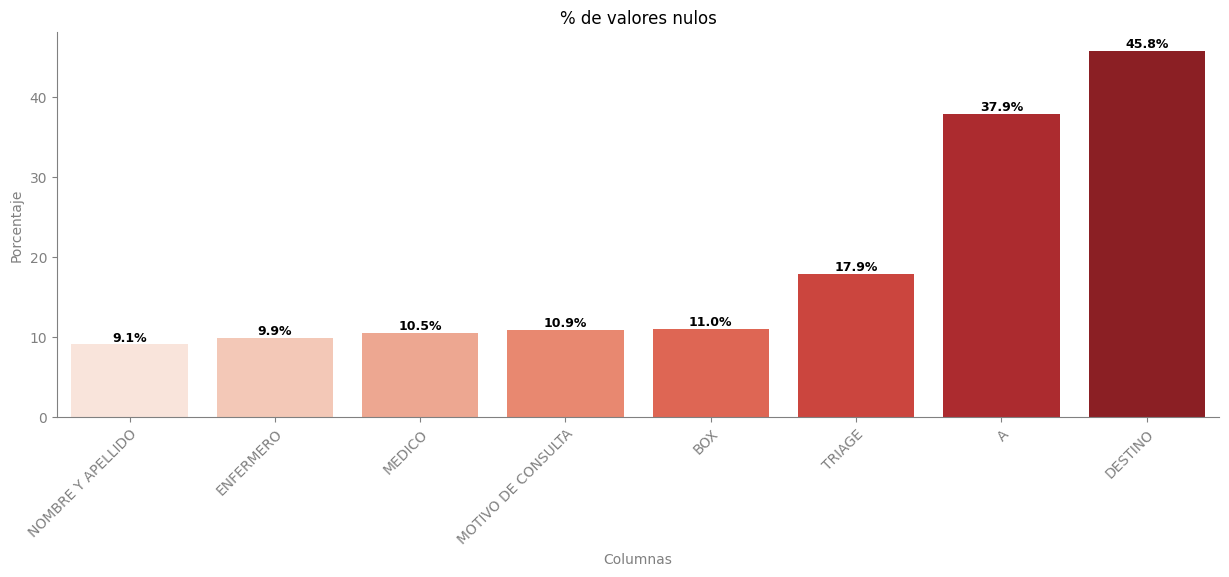

In [40]:
plt.figure(figsize=(15,5))
ax = sns.barplot(x=missing.index,y=missing.values, hue=missing.index, palette='Reds')
for i, v in enumerate(missing):
    plt.text(i, v, f'{v:.1f}%', ha='center', va='bottom',size=9, fontweight='black')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
plt.title('% de valores nulos')
plt.xlabel('Columnas')
plt.ylabel('Porcentaje')
plot_style(ax)